In [1]:
import pandas as pd

In [2]:
purchase_behaviour = pd.read_csv('QVI_purchase_behaviour.csv')
transaction_data = pd.read_excel('QVI_transaction_data.xlsx')

## Preview of Data

In [3]:
purchase_behaviour.head()

,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


In [4]:
purchase_behaviour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72637 entries, 0 to 72636
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   LYLTY_CARD_NBR    72637 non-null  int64 
 1   LIFESTAGE         72637 non-null  object
 2   PREMIUM_CUSTOMER  72637 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [5]:
transaction_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  object 
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), object(1)
memory usage: 16.2+ MB


In [6]:
transaction_data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


## Data Cleaning of Purchasing and Transaction Behaviour

In [7]:
purchase_behaviour.isnull().sum()

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

In [8]:
purchase_behaviour.duplicated().sum()   

np.int64(0)

In [9]:
purchase_behaviour.dtypes

LYLTY_CARD_NBR       int64
LIFESTAGE           object
PREMIUM_CUSTOMER    object
dtype: object

In [10]:
purchase_behaviour.describe()

,LYLTY_CARD_NBR
count,7.263700e+04
mean,1.361859e+05
std,8.989293e+04
min,1.000000e+03
25%,6.620200e+04
50%,1.340400e+05
75%,2.033750e+05
max,2.373711e+06


In [11]:
transaction_data.isnull().sum()

DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64

In [12]:
transaction_data.duplicated().sum()  

np.int64(1)

In [13]:
# Remove duplicate rows
transaction_data = transaction_data.drop_duplicates()

In [14]:
transaction_data.dtypes

DATE                int64
STORE_NBR           int64
LYLTY_CARD_NBR      int64
TXN_ID              int64
PROD_NBR            int64
PROD_NAME          object
PROD_QTY            int64
TOT_SALES         float64
dtype: object

In [15]:
transaction_data.describe()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264835.000000,264835.000000,2.648350e+05,2.648350e+05,264835.000000,264835.000000,264835.000000
mean,43464.036600,135.080216,1.355496e+05,1.351584e+05,56.583201,1.907308,7.304205
std,105.389336,76.784306,8.058011e+04,7.813316e+04,32.826692,0.643655,3.083231
min,43282.000000,1.000000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,43373.000000,70.000000,7.002100e+04,6.760100e+04,28.000000,2.000000,5.400000
50%,43464.000000,130.000000,1.303580e+05,1.351380e+05,56.000000,2.000000,7.400000
75%,43555.000000,203.000000,2.030945e+05,2.027015e+05,85.000000,2.000000,9.200000
max,43646.000000,272.000000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt


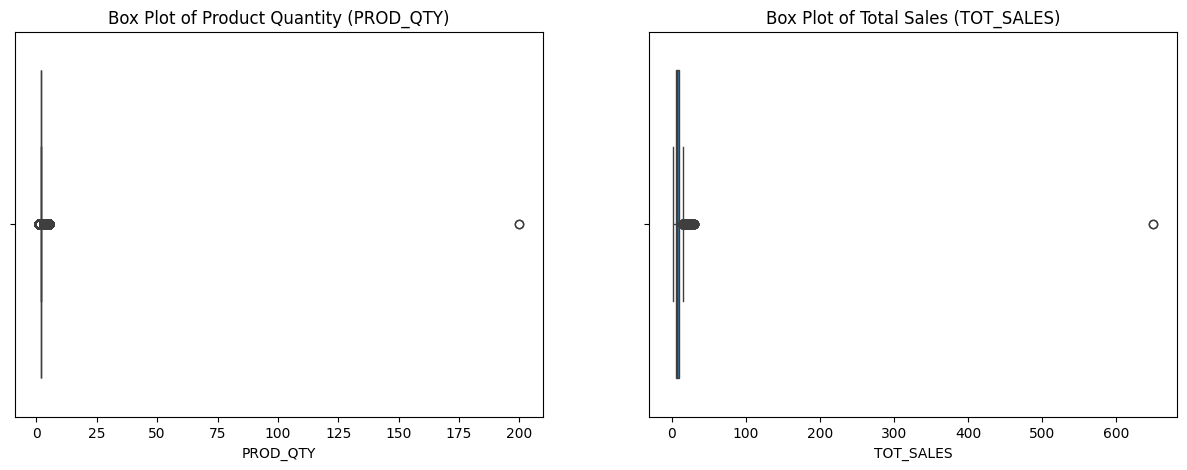

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(
    ax = axes[0],
    x = transaction_data['PROD_QTY']
)
axes[0].set_title('Box Plot of Product Quantity (PROD_QTY)')

sns.boxplot(
    ax = axes[1],
    x = transaction_data['TOT_SALES']
)
axes[1].set_title('Box Plot of Total Sales (TOT_SALES)')

plt.show()

### Examining the outliers the Transaction Data of Prod Quality

In [18]:
# Look specifically at the extreme outlier
extreme_outlier = transaction_data[transaction_data['PROD_QTY'] == 200]
extreme_outlier



,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,43331,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,43605,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [19]:
# Check if this customer (LYLTY_CARD_NBR) has made other transactions
outlier_customer = extreme_outlier['LYLTY_CARD_NBR'].iloc[0]
transaction_data[transaction_data['LYLTY_CARD_NBR'] == outlier_customer]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,43331,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,43605,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [20]:
# Remove the commercial customer by their loyalty card number
transaction_data = transaction_data[transaction_data['LYLTY_CARD_NBR'] != outlier_customer]

### Calcuating Total Outliers for Sales

In [21]:
# Calculate IQR for 'TOT_SALE'
Q1 = transaction_data['TOT_SALES'].quantile(0.25)
Q3 = transaction_data['TOT_SALES'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find and display outliers
outliers = transaction_data[(transaction_data['TOT_SALES'] < lower_bound) | (transaction_data['TOT_SALES'] > upper_bound)]

print(f"Number of outliers based on TOT_SALES: {len(outliers)}")
print("A few examples of outliers:")
outliers.head(10)

Number of outliers based on TOT_SALES: 576
A few examples of outliers:


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
11,43332,8,8294,8221,114,Kettle Sensations Siracha Lime 150g,5,23.0
56,43601,74,74336,73182,84,GrnWves Plus Btroot & Chilli Jam 180g,5,15.5
72,43331,96,96203,96025,7,Smiths Crinkle Original 330g,5,28.5
100,43605,130,130108,134125,2,Cobs Popd Sour Crm &Chives Chips 110g,5,19.0
102,43600,133,133250,137666,30,Doritos Corn Chips Cheese Supreme 170g,4,17.6
124,43602,168,168219,170719,33,Cobs Popd Swt/Chlli &Sr/Cream Chips 110g,4,15.2
165,43602,222,222209,222693,40,Thins Chips Seasonedchicken 175g,5,16.5
191,43329,257,257258,257308,114,Kettle Sensations Siracha Lime 150g,4,18.4
193,43331,262,262126,262025,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,4,18.4


In [22]:
# Convert Excel integer date to datetime
# The origin for Excel is Dec 30, 1899
transaction_data['DATE'] = pd.to_datetime(transaction_data['DATE'], unit='D', origin='1899-12-30')

In [24]:
# How many unique product names are there?
transaction_data['PROD_NAME'].nunique()

114

In [27]:
# Show all unique product names in sorted order
sorted(transaction_data['PROD_NAME'].dropna().unique())


['Burger Rings 220g',
 'CCs Nacho Cheese    175g',
 'CCs Original 175g',
 'CCs Tasty Cheese    175g',
 'Cheetos Chs & Bacon Balls 190g',
 'Cheetos Puffs 165g',
 'Cheezels Cheese 330g',
 'Cheezels Cheese Box 125g',
 'Cobs Popd Sea Salt  Chips 110g',
 'Cobs Popd Sour Crm  &Chives Chips 110g',
 'Cobs Popd Swt/Chlli &Sr/Cream Chips 110g',
 'Dorito Corn Chp     Supreme 380g',
 'Doritos Cheese      Supreme 330g',
 'Doritos Corn Chip Mexican Jalapeno 150g',
 'Doritos Corn Chip Southern Chicken 150g',
 'Doritos Corn Chips  Cheese Supreme 170g',
 'Doritos Corn Chips  Nacho Cheese 170g',
 'Doritos Corn Chips  Original 170g',
 'Doritos Mexicana    170g',
 'Doritos Salsa       Medium 300g',
 'Doritos Salsa Mild  300g',
 'French Fries Potato Chips 175g',
 'Grain Waves         Sweet Chilli 210g',
 'Grain Waves Sour    Cream&Chives 210G',
 'GrnWves Plus Btroot & Chilli Jam 180g',
 'Infuzions BBQ Rib   Prawn Crackers 110g',
 'Infuzions Mango     Chutny Papadums 70g',
 'Infuzions SourCream&Herbs Veg St

In [31]:
import re
import pandas as pd

def clean_prod_name(name):
    if pd.isna(name):
        return name
    name = str(name).strip()
    name = re.sub(r'\s+', ' ', name)   # collapse multiple spaces into one
    return name

transaction_data['PROD_NAME_CLEAN'] = transaction_data['PROD_NAME'].apply(clean_prod_name)

# See what changed
transaction_data[['PROD_NAME', 'PROD_NAME_CLEAN']].drop_duplicates().head(20)

,PROD_NAME,PROD_NAME_CLEAN
0,Natural Chip Compny SeaSalt175g,Natural Chip Compny SeaSalt175g
1,CCs Nacho Cheese 175g,CCs Nacho Cheese 175g
2,Smiths Crinkle Cut Chips Chicken 170g,Smiths Crinkle Cut Chips Chicken 170g
3,Smiths Chip Thinly S/Cream&Onion 175g,Smiths Chip Thinly S/Cream&Onion 175g
4,Kettle Tortilla ChpsHny&Jlpno Chili 150g,Kettle Tortilla ChpsHny&Jlpno Chili 150g
5,Old El Paso Salsa Dip Tomato Mild 300g,Old El Paso Salsa Dip Tomato Mild 300g
6,Smiths Crinkle Chips Salt & Vinegar 330g,Smiths Crinkle Chips Salt & Vinegar 330g
7,Grain Waves Sweet Chilli 210g,Grain Waves Sweet Chilli 210g
8,Doritos Corn Chip Mexican Jalapeno 150g,Doritos Corn Chip Mexican Jalapeno 150g
9,Grain Waves Sour Cream&Chives 210G,Grain Waves Sour Cream&Chives 210G


In [34]:
changed_names = transaction_data[transaction_data['PROD_NAME'] != transaction_data['PROD_NAME_CLEAN']]
changed_names[['PROD_NAME', 'PROD_NAME_CLEAN']].drop_duplicates()

,PROD_NAME,PROD_NAME_CLEAN
0,Natural Chip Compny SeaSalt175g,Natural Chip Compny SeaSalt175g
1,CCs Nacho Cheese 175g,CCs Nacho Cheese 175g
2,Smiths Crinkle Cut Chips Chicken 170g,Smiths Crinkle Cut Chips Chicken 170g
3,Smiths Chip Thinly S/Cream&Onion 175g,Smiths Chip Thinly S/Cream&Onion 175g
5,Old El Paso Salsa Dip Tomato Mild 300g,Old El Paso Salsa Dip Tomato Mild 300g
...,...,...
487,Natural ChipCo Sea Salt & Vinegr 175g,Natural ChipCo Sea Salt & Vinegr 175g
521,RRD SR Slow Rst Pork Belly 150g,RRD SR Slow Rst Pork Belly 150g
528,RRD Pc Sea Salt 165g,RRD Pc Sea Salt 165g
549,Smith Crinkle Cut Bolognese 150g,Smith Crinkle Cut Bolognese 150g


## Merge Data

In [35]:
merged_data = pd.merge(transaction_data, purchase_behaviour, on='LYLTY_CARD_NBR', how='left')

merged_data.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PROD_NAME_CLEAN,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,Natural Chip Compny SeaSalt175g,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3,CCs Nacho Cheese 175g,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,Smiths Crinkle Cut Chips Chicken 170g,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,Smiths Chip Thinly S/Cream&Onion 175g,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,Kettle Tortilla ChpsHny&Jlpno Chili 150g,MIDAGE SINGLES/COUPLES,Budget
